Quantum K-Nearest Neighbors (QKNN) — Phishing URL Detection

This notebook implements a **Quantum K-Nearest Neighbors** classifier using PennyLane.
Instead of Euclidean distance, it measures similarity between samples via **quantum fidelity**:


F(x_i, x_j) = |<ψ(x_i)|ψ(x_j)>|²
D(x_i, x_j) = 1 - F(x_i, x_j)

Encoding: angle encoding with RY gates on a 4-qubit circuit.  
Data pipeline is identical to the classical models for a fair comparison.

## 1. Imports & Config

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.45.0


In [2]:
CONFIG = {
    "data_path":        "../preprocessing-dataset/processed_data.csv",
    "result_dir":       "result",
    "text_column":      "processed_text",
    "label_column":     "Label",
    "url_column":       "URL",
    "sample_size":      5000,
    "test_size":        0.2,
    "random_state":     42,
    "svd_components":   50,
    "n_qubits":         4,
    "n_pca_components": 4,
    "qknn_train_size":  500,
    "k_candidates":     [3, 5, 7],
}

os.makedirs(CONFIG["result_dir"], exist_ok=True)
print("Config loaded. Result dir ready.")

Config loaded. Result dir ready.


Load & Sample Data random sample of 5 000 rows.

In [3]:
df_full = pd.read_csv(CONFIG["data_path"])
print(f"Full dataset shape: {df_full.shape}")

df, _ = train_test_split(
    df_full,
    train_size=CONFIG["sample_size"],
    random_state=CONFIG["random_state"],
    stratify=df_full[CONFIG["label_column"]],
)
df = df.reset_index(drop=True)

print(f"Sampled shape: {df.shape}")
print(f"Label distribution:\n{df[CONFIG['label_column']].value_counts()}")
df.head()

Full dataset shape: (549346, 3)
Sampled shape: (5000, 3)
Label distribution:
Label
good    3576
bad     1424
Name: count, dtype: int64


,URL,Label,processed_text
0,goldcoast.com.au/article/2011/11/02/362521_gol...,good,goldcoast com au articl 2011 11 02 362521 gold...
1,nypost.com/p/news/local/port_authority_boss_ch...,good,nypost com p news local port author boss chris...
2,yelp.ca/biz/redpath-sugar-museum-toronto,good,yelp ca biz redpath sugar museum toronto
3,theaircanadacentre.com/about/,good,theaircanadacentr com about
4,evri.com/organization/cinepop-0x2ff47,good,evri com organ cinepop 0x2ff47


URL Feature Engineering

Extract 6 handcrafted features from raw URL strings before the train/test split.

In [4]:
def extract_url_features(url: str) -> list:
    """Extract 6 numeric features from a raw URL string.

    Args:
        url: Raw URL string.

    Returns:
        List of [url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth].
    """
    return [
        len(url),
        url.count("."),
        sum(c.isdigit() for c in url),
        sum(c in "@-_=?&" for c in url),
        1 if re.search(r"\d+\.\d+\.\d+\.\d+", url) else 0,
        max(0, len(url.split("/")[2].split(".")) - 2) if "//" in url else 0,
    ]


url_features = np.array(
    [extract_url_features(str(u)) for u in df[CONFIG["url_column"]].fillna("")]
)
print(f"URL feature matrix shape: {url_features.shape}")
print("Columns: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth")

URL feature matrix shape: (5000, 6)
Columns: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth


Train/Test Split (80/20)

In [5]:
y = df[CONFIG["label_column"]].values
text_col = df[CONFIG["text_column"]].fillna("").astype(str).values

(
    text_train, text_test,
    url_feat_train, url_feat_test,
    y_train, y_test,
) = train_test_split(
    text_col, url_features, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

print(f"Train samples: {len(text_train)}")
print(f"Test samples:  {len(text_test)}")

Train samples: 4000
Test samples:  1000


TF-IDF Vectorization

Convert cleaned URL text to TF-IDF features. Fit on train only.

In [6]:
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_features=50000,
)
x_train_tfidf = tfidf.fit_transform(text_train)
x_test_tfidf  = tfidf.transform(text_test)

print(f"TF-IDF train shape: {x_train_tfidf.shape}")
print(f"TF-IDF test shape:  {x_test_tfidf.shape}")

TF-IDF train shape: (4000, 2303)
TF-IDF test shape:  (1000, 2303)


TruncatedSVD Dimensionality Reduction

Reduce sparse TF-IDF matrix to 50 dense dimensions. Fit on train only.

In [7]:
svd = TruncatedSVD(
    n_components=CONFIG["svd_components"],
    random_state=CONFIG["random_state"],
)
x_train_svd = svd.fit_transform(x_train_tfidf)
x_test_svd  = svd.transform(x_test_tfidf)

explained_var = svd.explained_variance_ratio_.sum()
print(f"SVD dims: {x_train_svd.shape[1]}")
print(f"Explained variance: {explained_var:.2%}")

SVD dims: 50
Explained variance: 33.85%


Combine Features + StandardScaler

Stack SVD features and 6 URL features, then standardize. Fit on train only.

In [8]:
x_train_combined = np.hstack([x_train_svd, url_feat_train])
x_test_combined  = np.hstack([x_test_svd,  url_feat_test])

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_combined)
x_test_scaled  = scaler.transform(x_test_combined)

print(f"Combined + scaled train shape: {x_train_scaled.shape}")
print(f"Combined + scaled test shape:  {x_test_scaled.shape}")

Combined + scaled train shape: (4000, 56)
Combined + scaled test shape:  (1000, 56)


## 8. PCA to 4 Dimensions

Reduce to 4 components — one per qubit. Fit on train only.

In [9]:
pca = PCA(
    n_components=CONFIG["n_pca_components"],
    random_state=CONFIG["random_state"],
)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca  = pca.transform(x_test_scaled)

explained_pca = pca.explained_variance_ratio_.sum()
print(f"PCA output shape (train): {x_train_pca.shape}")
print(f"PCA explained variance:   {explained_pca:.2%}")

PCA output shape (train): (4000, 4)
PCA explained variance:   12.76%


Normalize to [0, π]

Scale PCA outputs to the range [0, π] so they can be used as RY rotation angles.
MinMaxScaler fitted on train only.

In [10]:
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
x_train_angles = angle_scaler.fit_transform(x_train_pca)
x_test_angles  = angle_scaler.transform(x_test_pca)

print(f"Angle-encoded train range: [{x_train_angles.min():.4f}, {x_train_angles.max():.4f}]")
print(f"Angle-encoded test range:  [{x_test_angles.min():.4f}, {x_test_angles.max():.4f}]")
print(f"Shape: {x_train_angles.shape}  (samples × qubits)")

Angle-encoded train range: [0.0000, 3.1416]
Angle-encoded test range:  [-0.0598, 3.1389]
Shape: (4000, 4)  (samples × qubits)


Quantum Device & Fidelity Circuit

Set up a 4-qubit PennyLane device and define the fidelity kernel:

1. Encode `x1` with `AngleEmbedding` (RY gates)
2. Apply the adjoint encoding of `x2` (reverses the circuit)
3. Measure probability of the |0000⟩ state → this equals `|⟨ψ(x1)|ψ(x2)⟩|²`

In [11]:
n_qubits: int = CONFIG["n_qubits"]
dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def fidelity_circuit(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """Compute fidelity between two angle-encoded quantum states.

    Args:
        x1: First sample, shape (n_qubits,), values in [0, π].
        x2: Second sample, shape (n_qubits,), values in [0, π].

    Returns:
        Probability distribution over all 2^n_qubits basis states.
        probs[0] = probability of |0...0⟩ = quantum fidelity F(x1, x2).
    """
    qml.AngleEmbedding(x1, wires=range(n_qubits), rotation="Y")
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(n_qubits), rotation="Y")
    return qml.probs(wires=range(n_qubits))


def quantum_fidelity(x1: np.ndarray, x2: np.ndarray) -> float:
    """Return the quantum fidelity F(x1, x2) = |<ψ(x1)|ψ(x2)>|².

    Args:
        x1: First angle-encoded sample.
        x2: Second angle-encoded sample.

    Returns:
        Scalar fidelity in [0, 1].
    """
    probs = fidelity_circuit(x1, x2)
    return float(probs[0])


# Quick sanity check
x_sample = x_train_angles[0]
self_fidelity = quantum_fidelity(x_sample, x_sample)
print(f"Self-fidelity (should be ~1.0): {self_fidelity:.6f}")
cross_fidelity = quantum_fidelity(x_train_angles[0], x_train_angles[1])
print(f"Cross-fidelity sample 0 vs 1:   {cross_fidelity:.6f}")
print(f"\nCircuit diagram:")
print(qml.draw(fidelity_circuit)(x_train_angles[0], x_train_angles[1]))

Self-fidelity (should be ~1.0): 1.000000
Cross-fidelity sample 0 vs 1:   0.903161

Circuit diagram:
0: ─╭AngleEmbedding(M0)─╭AngleEmbedding(M1)†─┤ ╭Probs
1: ─├AngleEmbedding(M0)─├AngleEmbedding(M1)†─┤ ├Probs
2: ─├AngleEmbedding(M0)─├AngleEmbedding(M1)†─┤ ├Probs
3: ─╰AngleEmbedding(M0)─╰AngleEmbedding(M1)†─┤ ╰Probs

M0 = 
[0.25963453 1.14553962 0.73254532 1.50085168]
M1 = 
[0.14227523 1.55029309 0.67204441 1.02870796]


Subsample Training Set for QKNN

QKNN has O(n²) cost. We use 500 training samples (stratified) and validate on a held-out
100-sample split to pick the best k.

In [12]:
# Stratified subsample of 500 from the 4000-sample train set
idx_sub, idx_val_inner = train_test_split(
    np.arange(len(x_train_angles)),
    train_size=CONFIG["qknn_train_size"],
    random_state=CONFIG["random_state"],
    stratify=y_train,
)

# 100-sample validation split for k selection
idx_val_inner = idx_val_inner[:100]

x_qknn_train  = x_train_angles[idx_sub]        # (500, 4)
y_qknn_train  = y_train[idx_sub]                # (500,)
x_qknn_val    = x_train_angles[idx_val_inner]   # (100, 4)
y_qknn_val    = y_train[idx_val_inner]          # (100,)

print(f"QKNN train samples: {x_qknn_train.shape[0]}")
print(f"QKNN val samples:   {x_qknn_val.shape[0]}")
print(f"Test samples:       {x_test_angles.shape[0]}")
print(f"\nTrain label distribution: {dict(zip(*np.unique(y_qknn_train, return_counts=True)))}")

QKNN train samples: 500
QKNN val samples:   100
Test samples:       1000

Train label distribution: {'bad': np.int64(142), 'good': np.int64(358)}


Compute Fidelity Matrix

Compute fidelity between every test sample and every QKNN training sample.
Shape: (n_test=1000, n_train=500). Also compute train×val for k selection.

This is the slow step (~15-30 min). The result is saved to `result/fidelity_matrix.npy`.

In [13]:
def compute_fidelity_matrix(
    x_query: np.ndarray,
    x_train: np.ndarray,
    desc: str = "Fidelity",
) -> np.ndarray:
    """Compute pairwise quantum fidelity matrix between query and train sets.

    Args:
        x_query: Query samples, shape (n_query, n_qubits).
        x_train: Training samples, shape (n_train, n_qubits).
        desc: Label for the tqdm progress bar.

    Returns:
        Fidelity matrix of shape (n_query, n_train), values in [0, 1].
    """
    n_query = x_query.shape[0]
    n_train = x_train.shape[0]
    matrix = np.zeros((n_query, n_train), dtype=np.float32)

    for i in tqdm(range(n_query), desc=desc, unit="sample"):
        for j in range(n_train):
            matrix[i, j] = quantum_fidelity(x_query[i], x_train[j])

    return matrix


fidelity_matrix_path = os.path.join(CONFIG["result_dir"], "fidelity_matrix.npy")
val_fidelity_path    = os.path.join(CONFIG["result_dir"], "fidelity_matrix_val.npy")

# --- Validation fidelity matrix (100 × 500) for k selection ---
if os.path.exists(val_fidelity_path):
    print("Loading cached val fidelity matrix...")
    F_val = np.load(val_fidelity_path)
else:
    print("Computing val fidelity matrix (100 × 500)...")
    F_val = compute_fidelity_matrix(x_qknn_val, x_qknn_train, desc="Val fidelity")
    np.save(val_fidelity_path, F_val)
    print(f"Val fidelity matrix saved → {val_fidelity_path}")

print(f"Val fidelity matrix shape: {F_val.shape}")

# --- Test fidelity matrix (1000 × 500) ---
if os.path.exists(fidelity_matrix_path):
    print("\nLoading cached test fidelity matrix...")
    F_test = np.load(fidelity_matrix_path)
else:
    print("\nComputing test fidelity matrix (1000 × 500)...")
    F_test = compute_fidelity_matrix(x_test_angles, x_qknn_train, desc="Test fidelity")
    np.save(fidelity_matrix_path, F_test)
    print(f"Test fidelity matrix saved → {fidelity_matrix_path}")

print(f"Test fidelity matrix shape: {F_test.shape}")

Computing val fidelity matrix (100 × 500)...


Val fidelity: 100%|██████████| 100/100 [05:48<00:00,  3.49s/sample]


Val fidelity matrix saved → result\fidelity_matrix_val.npy
Val fidelity matrix shape: (100, 500)

Computing test fidelity matrix (1000 × 500)...


Test fidelity: 100%|██████████| 1000/1000 [1:05:57<00:00,  3.96s/sample]

Test fidelity matrix saved → result\fidelity_matrix.npy
Test fidelity matrix shape: (1000, 500)


## 13. QKNN Classification — Try k = 3, 5, 7

For each k, find the k nearest neighbors (highest fidelity) and take a majority vote.

In [14]:
def qknn_predict(
    fidelity_matrix: np.ndarray,
    y_train_labels: np.ndarray,
    k: int,
) -> np.ndarray:
    """Predict labels using precomputed fidelity matrix and majority vote.

    Args:
        fidelity_matrix: Shape (n_query, n_train). Higher = more similar.
        y_train_labels: Training labels, shape (n_train,).
        k: Number of nearest neighbors.

    Returns:
        Predicted labels, shape (n_query,).
    """
    # Highest fidelity = most similar → descending sort
    top_k_indices = np.argsort(fidelity_matrix, axis=1)[:, -k:]  # (n_query, k)
    predictions = []
    for row_idx in range(fidelity_matrix.shape[0]):
        neighbor_labels = y_train_labels[top_k_indices[row_idx]]
        unique_labels, counts = np.unique(neighbor_labels, return_counts=True)
        predictions.append(unique_labels[np.argmax(counts)])
    return np.array(predictions)


# --- Pick best k on validation set ---
print("Evaluating k candidates on validation set (100 samples)...\n")
val_results: dict[int, float] = {}
for k in CONFIG["k_candidates"]:
    y_val_pred = qknn_predict(F_val, y_qknn_train, k)
    acc = accuracy_score(y_qknn_val, y_val_pred)
    val_results[k] = acc
    print(f"  k={k}: val accuracy = {acc:.4f}")

best_k: int = max(val_results, key=val_results.get)
print(f"\nBest k: {best_k}  (val accuracy: {val_results[best_k]:.4f})")

Evaluating k candidates on validation set (100 samples)...

  k=3: val accuracy = 0.8300
  k=5: val accuracy = 0.8700
  k=7: val accuracy = 0.8700

Best k: 5  (val accuracy: 0.8700)


## 14. Evaluate Best k on Test Set

In [15]:
y_pred   = qknn_predict(F_test, y_qknn_train, best_k)
test_acc = accuracy_score(y_test, y_pred)
report   = classification_report(y_test, y_pred, target_names=["bad", "good"])

print(f"Test accuracy (k={best_k}): {test_acc:.4f}\n")
print(report)

Test accuracy (k=5): 0.7780

              precision    recall  f1-score   support

         bad       0.67      0.43      0.52       285
        good       0.80      0.92      0.86       715

    accuracy                           0.78      1000
   macro avg       0.74      0.67      0.69      1000
weighted avg       0.76      0.78      0.76      1000



## 15. Save Classification Report

In [16]:
report_path = os.path.join(CONFIG["result_dir"], "classification_report_qknn.txt")
with open(report_path, "w") as f:
    f.write(f"Best k (val accuracy): {best_k}\n")
    f.write(f"Test accuracy:         {test_acc:.4f}\n\n")
    f.write(report)

print(f"Classification report saved → {report_path}")

Classification report saved → result\classification_report_qknn.txt


## 16. Plot & Save Confusion Matrix

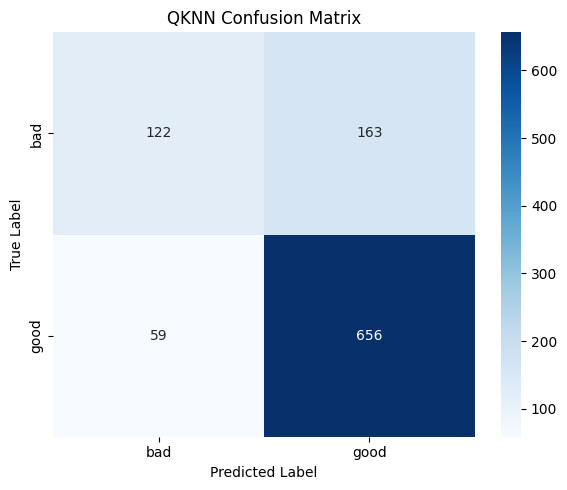

Confusion matrix saved → result\confusion_matrix_qknn.png


In [17]:
cm     = confusion_matrix(y_test, y_pred, labels=["bad", "good"])
labels = ["bad", "good"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_title("QKNN Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix_qknn.png")
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrix saved → {cm_path}")

## 17. Summary

In [ ]:
# print("=" * 55)
# print("  QKNN — Phishing URL Detection — Final Summary")
# print("=" * 55)
# print("\n[Config]")
# for key, val in CONFIG.items():
#     print(f"  {key:<22}: {val}")
# print("\n[Pipeline]")
# print(f"  TF-IDF max_features      : 50 000")
# print(f"  SVD explained variance   : {svd.explained_variance_ratio_.sum():.2%}")
# print(f"  PCA explained variance   : {pca.explained_variance_ratio_.sum():.2%}")
# print(f"  Angle range              : [0, π]")
# print("\n[QKNN]")
# print(f"  n_qubits                 : {n_qubits}")
# print(f"  Encoding                 : AngleEmbedding (RY)")
# print(f"  Similarity metric        : Quantum fidelity |<ψ(x1)|ψ(x2)>|²")
# print(f"  QKNN train samples       : {x_qknn_train.shape[0]}")
# print(f"  k candidates evaluated   : {CONFIG['k_candidates']}")
# print(f"  Best k                   : {best_k}")
# print("\n[Results]")
# for k, acc in val_results.items():
#     marker = " ← best" if k == best_k else ""
#     print(f"  k={k}: val accuracy = {acc:.4f}{marker}")
# print(f"\n  Test accuracy (k={best_k})     : {test_acc:.4f}")
# print("\n[Saved files]")
# print(f"  {report_path}")
# print(f"  {cm_path}")
# print(f"  {fidelity_matrix_path}")
# print("=" * 55)

  QKNN — Phishing URL Detection — Final Summary

[Config]
  data_path             : ../preprocessing-dataset/processed_data.csv
  result_dir            : result
  text_column           : processed_text
  label_column          : Label
  url_column            : URL
  sample_size           : 5000
  test_size             : 0.2
  random_state          : 42
  svd_components        : 50
  n_qubits              : 4
  n_pca_components      : 4
  qknn_train_size       : 500
  k_candidates          : [3, 5, 7]

[Pipeline]
  TF-IDF max_features      : 50 000
  SVD explained variance   : 33.85%
  PCA explained variance   : 12.76%
  Angle range              : [0, π]

[QKNN]
  n_qubits                 : 4
  Encoding                 : AngleEmbedding (RY)
  Similarity metric        : Quantum fidelity |<ψ(x1)|ψ(x2)>|²
  QKNN train samples       : 500
  k candidates evaluated   : [3, 5, 7]
  Best k                   : 5

[Results]
  k=3: val accuracy = 0.8300
  k=5: val accuracy = 0.8700 ← best
  k=7: va